In [63]:
import sys
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


sys.path.append("scripts/utils/")
from correlation_object import VMAutocorrelationObject
from experimental_data_class import AutocorrelationData, SegmentationData


In [84]:
param = "hh"                # hh, AA, VV, vv
correlation_type = "cell"   # "cell" or "field"

density = 1900

# Load data

In [85]:
# LOAD EXPERIMENTAL DATA
datasets = [#"holomonitor_20240319_A1-13",
            "holomonitor_20240301_B1-4",
            #"holomonitor_20240319_B1-11",
            #"holomonitor_20240319_A1-9"]
            ]


binsize = 200

masks = []
corr_experiment = AutocorrelationData(f"")

# Add experimental data
for dataset in datasets:

    cellprop = SegmentationData()
    cellprop.load(f"../../../../hdd_data/silja/VertexModel_data/experimental/processed/{dataset}/cell_props.p")
    cellprop.add_density()

    mask = (cellprop.density > density - binsize / 2) * (cellprop.density < density + binsize / 2)
    if param == "vv":
        mask = mask[1:]

    if correlation_type == "cell":
        tmp_correlations = AutocorrelationData(f"../../../../hdd_data/silja/VertexModel_data/experimental/processed/{dataset}/cell_autocorr.p")

    elif correlation_type == "field":
        tmp_correlations = AutocorrelationData(f"../../../../hdd_data/silja/VertexModel_data/experimental/processed/{dataset}/field_autocorr.p")
        
    else:
        print("Error: Do not recognize correlation type")

    corr_experiment.r_array = tmp_correlations.r_array[param]
    corr_experiment.t_array = tmp_correlations.t_array[param] / 12
    corr_experiment.spatial[param]  = np.ma.mean(tmp_correlations.spatial[param][mask],  axis=0)
    corr_experiment.temporal[param] = np.ma.mean(tmp_correlations.temporal[param][mask], axis=0)

State loaded from ../../../../hdd_data/silja/VertexModel_data/experimental/processed/holomonitor_20240301_B1-4/cell_props.p.
State loaded from ../../../../hdd_data/silja/VertexModel_data/experimental/processed/holomonitor_20240301_B1-4/cell_autocorr.p.


In [86]:
# LOAD SIMULATION DATA
date  = [20260505, 20260505]
gamma = [27, 13]
lmbd  = [100, 100]
v0    = [120, 100]
tau   = [120, 100]
eta   = [200, 100]


paths = [f"nodivision_{date[i]}_N42_L600_gamma{gamma[i]}_lambda{lmbd[i]}_v0{v0[i]}_taup{tau[i]}_eta{eta[i]}.p" for i in range(2)]

# Load data
corr_simulation = []
for path in paths:
    corr_simulation.append(VMAutocorrelationObject(out_path=path))

colors = mpl.colormaps["Reds"](np.linspace(0.4, 0.9, len(paths)))

State loaded from ../../../../hdd_data/silja/VertexModel_data/simulated/processed/nodivision_20260505_N42_L600_gamma27_lambda100_v0120_taup120_eta200.autocorr.
State loaded from ../../../../hdd_data/silja/VertexModel_data/simulated/processed/nodivision_20260505_N42_L600_gamma13_lambda100_v0100_taup100_eta100.autocorr.


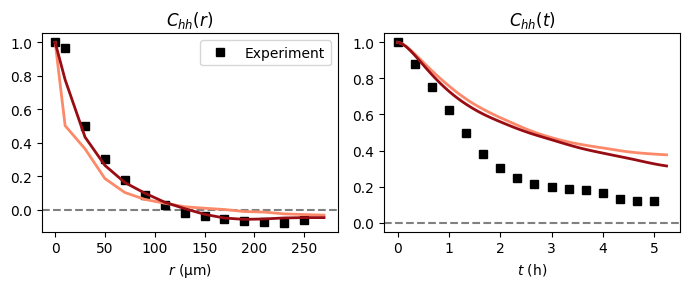

In [87]:
# create figure
plt.figure(figsize=(7,3))
plt.subplot(121)
plt.xlabel(r"$r$ (µm)")
plt.title(rf"$C_{{{param}}}(r)$");

plt.axhline(0, ls="dashed", c="gray")
plt.plot(corr_experiment.r_array,
         corr_experiment.spatial[param], 
         'ks', label='Experiment')

for i in range(len(paths)):
    plt.plot(corr_simulation[i].r_array[param],
            corr_simulation[i].spatial[param],
            c=colors[i], lw=2)

plt.legend()

# create subfigure
plt.subplot(122)
plt.xlabel(r"$t$ (h)")
plt.title(rf"$C_{{{param}}}(t)$");

plt.axhline(0, ls="dashed", c="gray")
plt.plot(corr_experiment.t_array[0:-1:4],
         corr_experiment.temporal[param][0:-1:4],
         'ks', label="Experiment")

for i in range(len(paths)):
    plt.plot(corr_simulation[i].t_array[param],
            corr_simulation[i].temporal[param],
            c=colors[i], lw=2)

# save
plt.tight_layout()
# # plt.savefig(f"results/tmp/correlation_comparison_{param}.png", dpi=300)